Name: Nikhil Sanjay Patil

Roll no: 06

PRN:12311506

Class: TY CSAI B Batch 1

Problem Statement:  Implementation of RNN model for Stock Price Prediction

/tmp/ipykernel_1766/3404704482.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0053
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 3.2287e-04
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.9595e-04
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 2.8629e-04
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 2.7083e-04
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 2.6600e-04
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.7112e-04
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.4786e-04
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 2.5225e-04
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 2.3729e-04
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


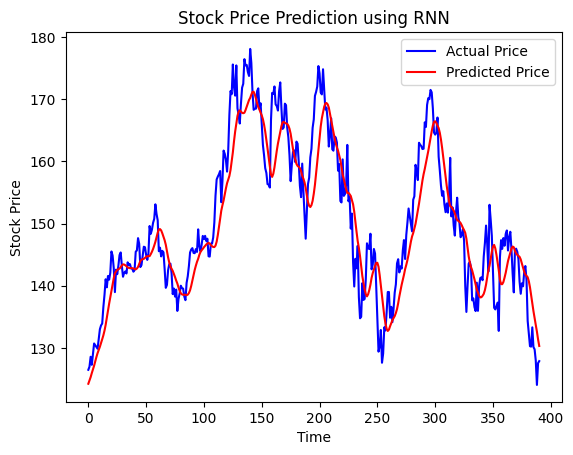

MSE: 27.907825904843115
RMSE: 5.282785809101398


In [ ]:
# Install dependency
!pip install yfinance

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import yfinance as yf

# Load data
data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')

df = data[['Close']]
df.head()

# Scaling
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

# Create dataset
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)


train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Build LSTM model
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train model
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

# Predictions
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Plot results
plt.plot(y_test_actual, color='blue', label='Actual Price')
plt.plot(predictions, color='red', label='Predicted Price')
plt.title("Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

# Evaluation
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)